# Analyse : regression_esserdaoui.py

Entraînement terminé !
Coefficient a (pente) : 0.4710
Coefficient b (biais) : 0.1138


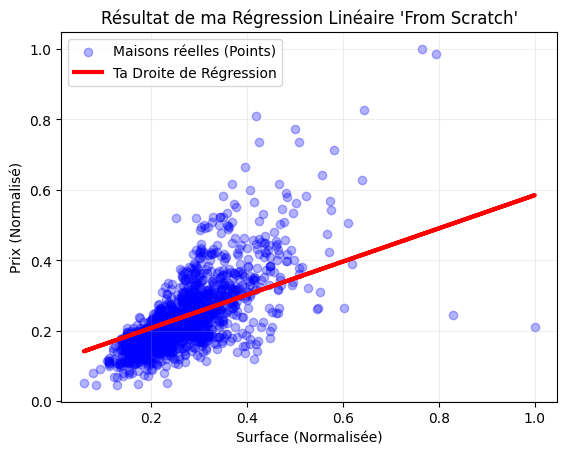

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. FONCTION DE RÉGRESSION LINÉAIRE (FROM SCRATCH)
# =========================================================
def RegreL(dataS, a, b, alpha, it=1000):
    history_J = []

    # Extraction des colonnes (X = Surface, Y = Prix)
    X = dataS[:, 0]
    Y = dataS[:, 1]
    m = len(Y)

    # Sauvegarde des maximums pour pouvoir dénormaliser plus tard si besoin
    x_max = np.max(X)
    y_max = np.max(Y)

    # -----------------------------------------------------
    # NORMALISATION (Mise à l'échelle entre 0 et 1)
    # -----------------------------------------------------
    # Crucial pour éviter que les calculs ne deviennent trop grands (Overflow)
    X_ = X / x_max
    Y_ = Y / y_max

    # -----------------------------------------------------
    # BOUCLE D'ENTRAÎNEMENT (DESCENTE DE GRADIENT)
    # -----------------------------------------------------
    for i in range(it):

        # A. CALCUL DE LA PRÉDICTION (Ligne droite : y = ax + b)
        Yp = a * X_ + b

        # B. CALCUL DU COÛT (MSE - Mean Squared Error)
        # On mesure la distance entre la droite et les points réels
        cost = (1 / (2 * m)) * np.sum((Yp - Y_)**2)
        history_J.append(cost)

        # C. CALCUL DES DÉRIVÉES PARTIELLES (LES GRADIENTS)
        # On cherche dans quelle direction ajuster 'a' et 'b'
        deriv_a = (1/m) * np.sum((Yp - Y_) * X_)
        deriv_b = (1/m) * np.sum(Yp - Y_)

        # D. MISE À JOUR DES PARAMÈTRES
        # On ajuste la pente (a) et l'ordonnée à l'origine (b)
        a = a - alpha * deriv_a
        b = b - alpha * deriv_b

    return a, b, history_J, x_max, y_max

# =========================================================
# 2. PRÉPARATION DES DONNÉES (KAGGLE / TRAIN.CSV)
# =========================================================

# Chargement des colonnes 46 (Surface) et 80 (Prix)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))

# Suppression des lignes contenant des valeurs vides (NaN)
dataset = dataset[~np.isnan(dataset).any(axis=1)]

# =========================================================
# 3. EXÉCUTION DE L'APPRENTISSAGE
# =========================================================

# On lance l'algorithme avec un Learning Rate (alpha) de 0.1
a_fin, b_fin, erreurs, mx, my = RegreL(dataset, 0.0, 0.0, 0.1)

print(f"Entraînement terminé !")
print(f"Coefficient a (pente) : {a_fin:.4f}")
print(f"Coefficient b (biais) : {b_fin:.4f}")

# =========================================================
# 4. VISUALISATION
# =========================================================

# Préparation des points pour l'affichage (données normalisées)
X_plot = dataset[:, 0] / mx
Y_plot = dataset[:, 1] / my

# Affichage des points réels (en bleu)
plt.scatter(X_plot, Y_plot, color='blue', alpha=0.3, label='Maisons réelles (Points)')

# Calcul et affichage de la droite de prédiction (en rouge)
Y_predite = a_fin * X_plot + b_fin
plt.plot(X_plot, Y_predite, color='red', linewidth=3, label='Ta Droite de Régression')

plt.title("Résultat de ma Régression Linéaire 'From Scratch'")
plt.xlabel("Surface (Normalisée)")
plt.ylabel("Prix (Normalisé)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Analyse : regression_sklearn_esserdaoui.py

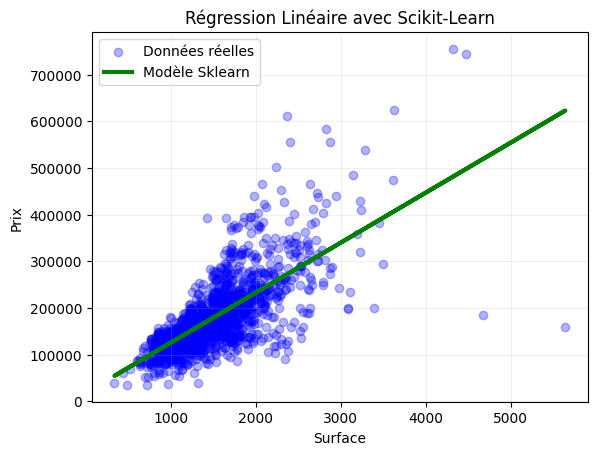

Coefficient (a) : 107.1304
Interception (b) : 18569.0259


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# =========================================================
# 1. PRÉPARATION DES DONNÉES (TRAIN.CSV)
# =========================================================

# Chargement : Surface (col 46) et Prix (col 80)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))

# Nettoyage des données : on enlève les lignes vides (NaN)
dataset = dataset[~np.isnan(dataset).any(axis=1)]

# X doit être une matrice (2D) pour Sklearn, d'où le .reshape(-1, 1)
X = dataset[:, 0].reshape(-1, 1)
Y = dataset[:, 1]

# =========================================================
# 2. CRÉATION ET ENTRAÎNEMENT DU MODÈLE
# =========================================================

# Création d'une instance de l'objet LinearRegression
# Sklearn utilise l'algorithme des Moindres Carrés Ordinaires (MCO)
model = LinearRegression()

# La méthode fit() prend les données d'entrée (X) et les résultats attendus (Y)
# Elle apprend automatiquement la relation mathématique (y = ax + b)
model.fit(X, Y)

# =========================================================
# 3. PRÉDICTION
# =========================================================

# predict() utilise les coefficients "a" et "b" trouvés pour calculer les prix
y_pred = model.predict(X)

# =========================================================
# 4. VISUALISATION DES RÉSULTATS
# =========================================================

# Affichage des points réels du dataset (en bleu)
plt.scatter(X, Y, color='blue', alpha=0.3, label='Données réelles')

# Affichage de la droite de régression trouvée par Sklearn (en vert)
plt.plot(X, y_pred, color='green', linewidth=3, label='Modèle Sklearn')

plt.title("Régression Linéaire avec Scikit-Learn")
plt.xlabel("Surface")
plt.ylabel("Prix")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# =========================================================
# 5. AFFICHAGE DES PARAMÈTRES APPRIS
# =========================================================

# Le coefficient 'a' (pente de la droite)
print(f"Coefficient (a) : {model.coef_[0]:.4f}")
# L'interception 'b' (ordonnée à l'origine)
print(f"Interception (b) : {model.intercept_:.4f}")

# Analyse : regression_Multiple_esserdaoui.py

--- RÉSULTATS DU MODÈLE ---
Coefficients (W) : 
[[ 6127.34365033]
 [  106.11917683]
 [31638.76199138]
 [ 8982.18061516]]
Erreur Moyenne Quadratique (MSE) : 1438289503.5826


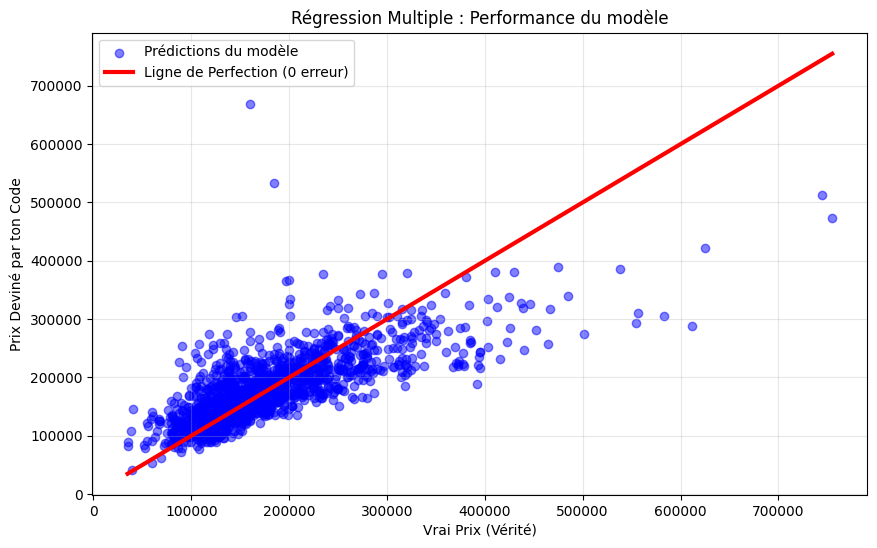

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. PRÉPARATION DES DONNÉES (FEATURES MULTIPLES)
# =========================================================

# Chargement de 4 colonnes : 3 caractéristiques (46, 47, 48) et le Prix (80)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 47, 48, 80))

# On retire les lignes contenant des valeurs manquantes (NaN)
dataset = dataset[~np.isnan(dataset).any(axis=1)]

# X : contient toutes les colonnes sauf la dernière (les variables explicatives)
X = dataset[:, :-1]

# y : contient la dernière colonne (la cible : le prix)
y = dataset[:, -1].reshape(-1, 1)

m = len(y)

# =========================================================
# 2. MÉTHODE DE L'ÉQUATION NORMALE (SOLUTION ANALYTIQUE)
# =========================================================

# A. AJOUT DU BIAIS (INTERCEPT)
# On ajoute une colonne remplie de 1 devant la matrice X
# Cela permet de calculer le coefficient 'b' en même temps que les poids 'w'
X_b = np.c_[np.ones((m, 1)), X]

# B. CALCUL MATHÉMATIQUE DIRECT
# Formule : W = (X.T * X)^-1 * X.T * y
XT = X_b.T                        # Transposée de la matrice
XR = XT.dot(X_b)                  # Produit matriciel : X.T * X
X_inv = np.linalg.inv(XR)         # Inversion de la matrice résultante
X_Y = XT.dot(y)                   # Produit matriciel : X.T * y

# W contient tous les coefficients finaux : [Biais, W1, W2, W3]
W = X_inv.dot(X_Y)

# =========================================================
# 3. ÉVALUATION DU MODÈLE
# =========================================================

# On calcule les prix prédits par le modèle pour chaque maison
y_pred = X_b.dot(W)

# Calcul de l'erreur moyenne au carré (MSE)
erreur = y_pred - y
mse = (1 / (2 * m)) * np.sum(erreur**2)

print(f"--- RÉSULTATS DU MODÈLE ---")
print(f"Coefficients (W) : \n{W}")
print(f"Erreur Moyenne Quadratique (MSE) : {mse:.4f}")

# =========================================================
# 4. VISUALISATION DES PERFORMANCES
# =========================================================

plt.figure(figsize=(10, 6))

# On compare le Vrai Prix vs le Prix Prédit
# Plus les points sont proches de la ligne rouge, plus le modèle est précis
plt.scatter(y, y_pred, color='blue', alpha=0.5, label='Prédictions du modèle')

# Ligne de Perfection : là où Prédiction == Réalité
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=3, label='Ligne de Perfection (0 erreur)')

plt.xlabel("Vrai Prix (Vérité)")
plt.ylabel("Prix Deviné par ton Code")
plt.title("Régression Multiple : Performance du modèle")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Analyse : regression_Multiple_Sklearn_esserdaoui.py

--- RÉSULTATS SKLEARN ---
Interception (Biais b) : 6127.3437
Coefficients (Poids a) : [  106.11917683 31638.76199138  8982.18061516]
Erreur Moyenne (MSE) : 2876579007.1651


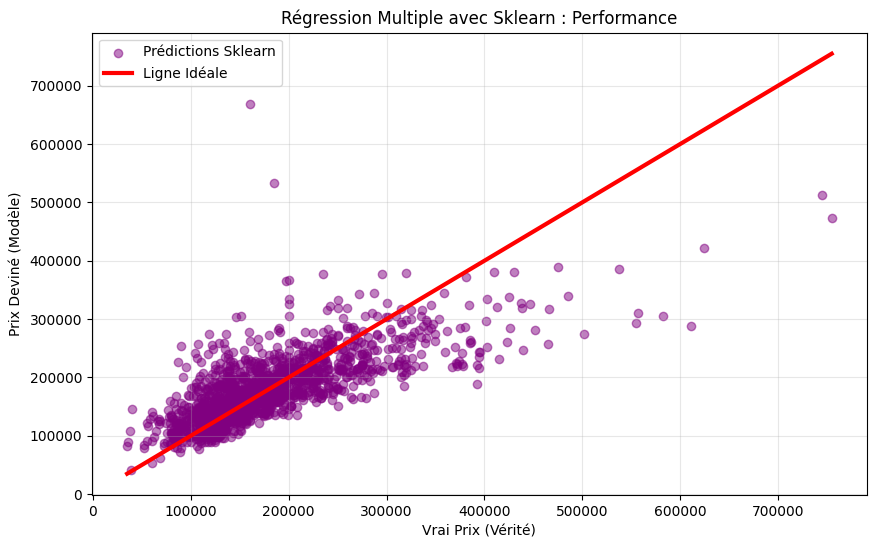

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# =========================================================
# 1. PRÉPARATION DES DONNÉES (MULTIPLE FEATURES)
# =========================================================

# Chargement des caractéristiques (46, 47, 48) et du Prix (80)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 47, 48, 80))

# Nettoyage : on supprime les lignes avec des valeurs manquantes (NaN)
dataset = dataset[~np.isnan(dataset).any(axis=1)]

# X : Les 3 premières colonnes (Surface, etc.)
# y : La dernière colonne (Prix)
X = dataset[:, :-1]
y = dataset[:, -1]

# =========================================================
# 2. CRÉATION ET ENTRAÎNEMENT DU MODÈLE
# =========================================================

# Création de l'objet de régression
# Sklearn gère automatiquement l'ajout du biais (la colonne de 1)
model = LinearRegression()

# Apprentissage automatique des coefficients (a1, a2, a3) et du biais (b)
model.fit(X, y)

# =========================================================
# 3. PRÉDICTIONS ET ÉVALUATION
# =========================================================

# Le modèle utilise ses coefficients appris pour deviner les prix
y_pred = model.predict(X)

# Calcul de l'erreur (MSE) avec les outils de Sklearn
mse = mean_squared_error(y, y_pred)

# =========================================================
# 4. AFFICHAGE DES PARAMÈTRES APPRIS
# =========================================================

print(f"--- RÉSULTATS SKLEARN ---")
# Valeur de départ quand toutes les caractéristiques sont à 0
print(f"Interception (Biais b) : {model.intercept_:.4f}")

# Coefficients d'importance pour chaque variable (a1, a2, a3)
print(f"Coefficients (Poids a) : {model.coef_}")

print(f"Erreur Moyenne (MSE) : {mse:.4f}")

# =========================================================
# 5. VISUALISATION DES PERFORMANCES
# =========================================================

plt.figure(figsize=(10, 6))

# Comparaison entre les prix réels et les prédictions
plt.scatter(y, y_pred, color='purple', alpha=0.5, label='Prédictions Sklearn')

# Ligne de perfection (où le prix deviné = vrai prix)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=3, label='Ligne Idéale')

plt.xlabel("Vrai Prix (Vérité)")
plt.ylabel("Prix Deviné (Modèle)")
plt.title("Régression Multiple avec Sklearn : Performance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Analyse : regression_Poly_esserdaoui.py

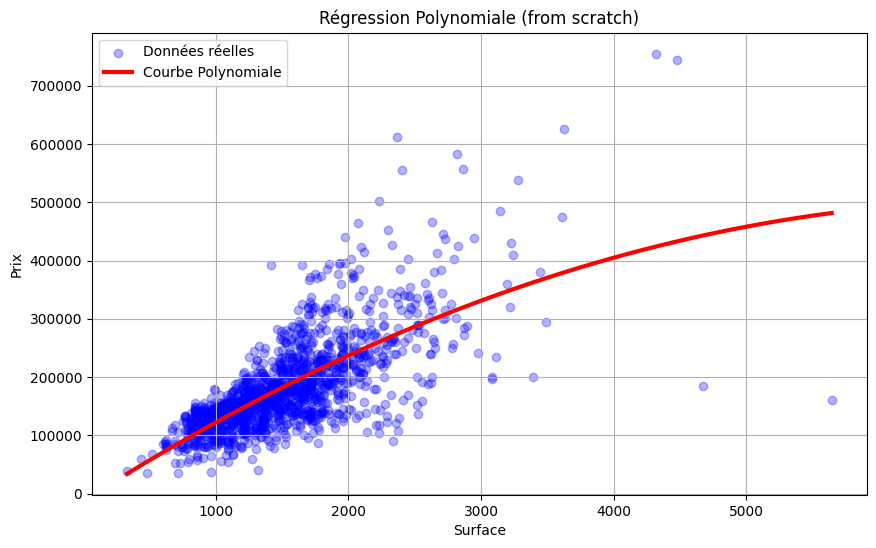

In [14]:
import numpy as np
import matplotlib.pyplot as plt

#On charge les données (Surface et Prix)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))

X_single = dataset[:, 0].reshape(-1, 1) # On stocke la colonne de surface
y = dataset[:, 1].reshape(-1, 1)        # On stocke les valeurs de prix

#On crée une matrice avec X et X au carré (X^2)
X_poly = np.c_[X_single, X_single**2]

m = len(y)

#On ajoute une colonne de 1 devant la matrice pour la valeur de départ
X_b = np.c_[np.ones((m, 1)), X_poly]

XT = X_b.T
#On calcule la transposée de la matrice

XR = XT.dot(X_b)
#On calcule la multiplication matricielle entre la matrice et sa transposée

X_inv = np.linalg.inv(XR)
#Ici on essaye de trouver l'inverse de la matrice

X_Y = XT.dot(y)

W = X_inv.dot(X_Y)
#On calcule les coefficients finaux

# --------------- Visualisation-------------------
plt.figure(figsize=(10, 6))
plt.scatter(X_single, y, color='blue', alpha=0.3, label='Données réelles')
x_line = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
x_line_b = np.c_[np.ones((100, 1)), x_line, x_line**2]
y_line = x_line_b.dot(W)
plt.plot(x_line, y_line, color='red', linewidth=3, label='Courbe Polynomiale')
plt.xlabel("Surface")
plt.ylabel("Prix")
plt.title("Régression Polynomiale (from scratch)")
plt.legend()
plt.grid(True)
plt.show()


# Analyse : regression_Poly_Sklearn_esserdaoui.py

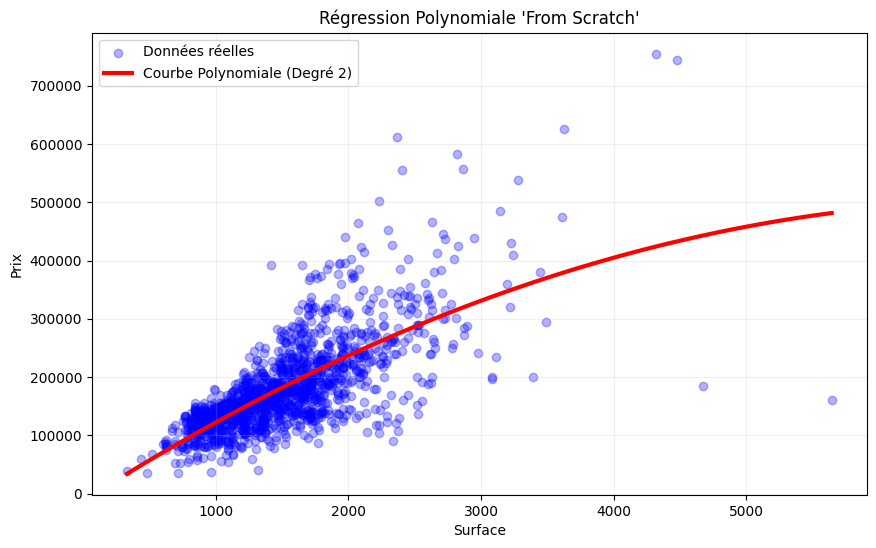

Coefficients appris : 
[[-1.32836885e+04]
 [ 1.45549389e+02]
 [-1.02504204e-02]]


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. PRÉPARATION DES DONNÉES (TRAIN.CSV)
# =========================================================

# Chargement de la Surface (46) et du Prix (80)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))

# Nettoyage des données manquantes
dataset = dataset[~np.isnan(dataset).any(axis=1)]

X_single = dataset[:, 0].reshape(-1, 1) # Surface
y = dataset[:, 1].reshape(-1, 1)        # Prix réel

# =========================================================
# 2. CRÉATION DES CARACTÉRISTIQUES POLYNOMIALES
# =========================================================

# On ne veut plus seulement 'x', on veut 'x' et 'x au carré'
# Cela permet au modèle de comprendre les courbures
X_poly = np.c_[X_single, X_single**2]

m = len(y)

# On ajoute la colonne de 1 pour le biais (intercept)
X_b = np.c_[np.ones((m, 1)), X_poly]

# =========================================================
# 3. SOLUTION PAR ÉQUATION NORMALE (MATRICES)
# =========================================================

# Calcul direct des coefficients sans itérations
# Formule : W = (X.T * X)^-1 * X.T * y
XT = X_b.T                        # Transposée
XR = XT.dot(X_b)                  # Produit X.T * X
X_inv = np.linalg.inv(XR)         # Inverse de la matrice
X_Y = XT.dot(y)                   # Produit X.T * y

# W contient maintenant : [Biais, Coeff_Surface, Coeff_Surface_Carré]
W = X_inv.dot(X_Y)

# =========================================================
# 4. VISUALISATION DE LA COURBE
# =========================================================

plt.figure(figsize=(10, 6))

# Affichage des points réels
plt.scatter(X_single, y, color='blue', alpha=0.3, label='Données réelles')

# Création d'une ligne lisse pour afficher la courbe
x_line = np.linspace(X_single.min(), X_single.max(), 100).reshape(-1, 1)
# On applique la même transformation polynomiale aux points de la ligne
x_line_b = np.c_[np.ones((100, 1)), x_line, x_line**2]
y_line = x_line_b.dot(W)

# Tracé de la courbe polynomiale (en rouge)
plt.plot(x_line, y_line, color='red', linewidth=3, label='Courbe Polynomiale (Degré 2)')

plt.xlabel("Surface")
plt.ylabel("Prix")
plt.title("Régression Polynomiale 'From Scratch'")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Coefficients appris : \n{W}")

Itération 0 : Erreur = 0.6852
Itération 500 : Erreur = 0.4726
Itération 1000 : Erreur = 0.4725
Itération 1500 : Erreur = 0.4725

RÉSULTATS FINAUX
Poids (w) : [2.10367428]
Biais (b) : 0.16884749541890748
Précision du modèle : 78.77%


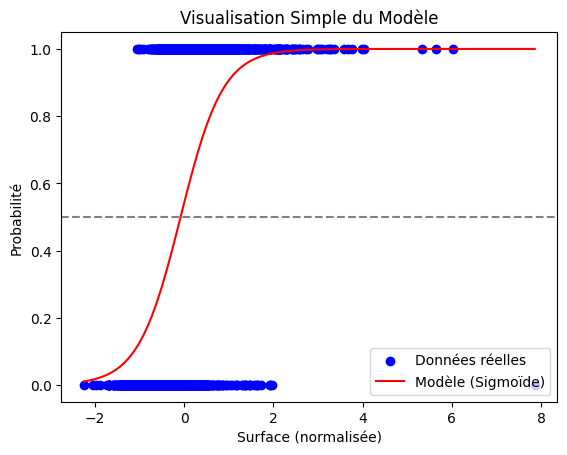

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. FONCTIONS MATHÉMATIQUES DE BASE
# =========================================================

# la fonction Sigmoid transforme n'importe quelle valeur réelle en probabilité (0 à 1)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# On utilisant la fonction cout pour mesure l'erreur du modèle
def calculer_cout(X, y, w, b, lambda_reg):
    m = X.shape[0]
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    # Epsilon évite de faire log(0) ce qui ferait planter le code
    epsilon = 1e-15

    # Formule Log Loss
    perte = -(1/m) * np.sum(y * np.log(y_pred + epsilon) + (1-y) * np.log(1 - y_pred + epsilon))

    # Formule Régularisation L2
    reg_F = (lambda_reg / (2*m)) * np.sum(np.square(w))

    return perte + reg_F

# =========================================================
# 2. ENTRAÎNEMENT DU MODÈLE (DESCENTE DE GRADIENT)
# =========================================================

def entrainer_modele(X, y, lr, iterations, lambda_reg):
    # n_samples : nombre de lignes | n_features : nombre de colonnes
    m, n = X.shape

    # Initialisation : on commence avec des poids à 0
    w = np.zeros(n)
    b = 0

    for i in range(iterations):
        # -----------------------------------------------------
        # A. CALCUL DE LA PRÉDICTION
        # -----------------------------------------------------
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        # -----------------------------------------------------
        # B. CALCUL DES GRADIENTS
        # -----------------------------------------------------
        # dw : erreur par rapport aux poids
        dw = (1/m) * np.dot(X.T, (y_pred - y)) + (lambda_reg / m) * w

        # db : erreur par rapport au biais
        db = (1/m) * np.sum(y_pred - y)

        # -----------------------------------------------------
        # C. MISE À JOUR DES PARAMÈTRES
        # -----------------------------------------------------
        # On descend la pente pour réduire l'erreur
        w -= lr * dw
        b -= lr * db

        # Affichage du coût tous les 500 cycles pour voir la progression
        if i % 500 == 0:
            cost = calculer_cout(X, y, w, b, lambda_reg)
            print(f"Itération {i} : Erreur = {cost:.4f}")

    return w, b

# =========================================================
# 3. PRÉDICTION
# =========================================================

def predire(X, w, b):
    # Calcul des probabilités
    z = np.dot(X, w) + b
    prob = sigmoid(z)
    # Si proba >= 0.5 -> Classe 1, sinon Classe 0
    return np.array([1 if p >= 0.5 else 0 for p in prob])

# =========================================================
# 4. CHARGEMENT ET PRÉPARATION DES DONNÉES (TRAIN.CSV)
# =========================================================

# Chargement : Surface (col 46) et Prix (col 80)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))

# Nettoyage des données manquantes (NaN)
dataset = dataset[~np.isnan(dataset).any(axis=1)]

X = dataset[:, 0].reshape(-1, 1) # Caractéristique (Surface)
y_brut = dataset[:, 1]           # Cible réelle (Prix)

# Transformation en classification binaire
y = (y_brut > np.median(y_brut)).astype(int)

# Normalisation : Crucial pour que le modèle apprenne correctement
X_norm = (X - np.mean(X)) / np.std(X)





# =========================================================
# 5. EXÉCUTION
# =========================================================

# Paramètres
LEARNING_RATE = 0.1
ITERATIONS = 2000
LAMBDA_REG = 0.01

# Lancement de l'apprentissage
poids_finaux, biais_final = entrainer_modele(X_norm, y, LEARNING_RATE, ITERATIONS, LAMBDA_REG)

# Calcul de la précision finale
predictions = predire(X_norm, poids_finaux, biais_final)
precision = np.mean(predictions == y) * 100

print("\n" + "="*40)
print(f"RÉSULTATS FINAUX")
print(f"Poids (w) : {poids_finaux}")
print(f"Biais (b) : {biais_final}")
print(f"Précision du modèle : {precision:.2f}%")
print("="*40)

# =========================================================
# 6. VISUALISATION DES RÉSULTATS
# =========================================================

x_courbe = np.linspace(X_norm.min(), X_norm.max(), 100).reshape(-1, 1)
# On calcule la probabilité pour chaque point avec tes poids finaux
y_proba = sigmoid(np.dot(x_courbe, poids_finaux) + biais_final)

# Affichage
# On affiche les vrais points du dataset (0 ou 1)
plt.scatter(X_norm, y, color='blue', label='Données réelles')
# On affiche la courbe que le modèle a apprise
plt.plot(x_courbe, y_proba, color='red', label='Modèle (Sigmoïde)')

# Ligne de décision à 0.5
plt.axhline(y=0.5, color='gray', linestyle='--')
plt.xlabel("Surface (normalisée)")
plt.ylabel("Probabilité")
plt.title("Visualisation Simple du Modèle")
plt.legend()
plt.show()

--- RÉSULTATS SKLEARN (LOGISTIQUE) ---
Biais (Intercept b) : 0.1655
Poids (Coefficient w) : 2.0775
Précision globale : 78.77%


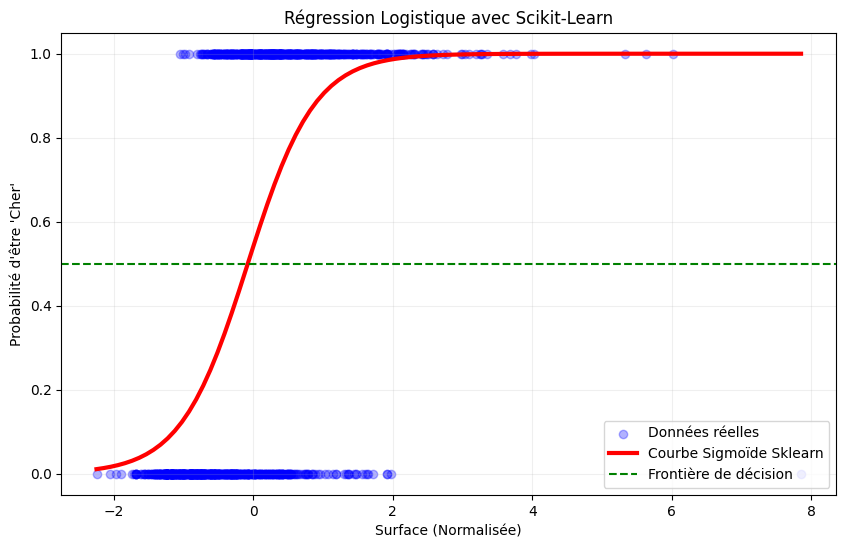

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# =========================================================
# 1. PRÉPARATION DES DONNÉES (TRAIN.CSV)
# =========================================================

# Chargement : Surface (46) et Prix (80)
dataset = np.genfromtxt('train.csv', delimiter=',', skip_header=1, usecols=(46, 80))
dataset = dataset[~np.isnan(dataset).any(axis=1)]

X = dataset[:, 0].reshape(-1, 1) # Caractéristique (Surface)
y_raw = dataset[:, 1]            # Prix réel

# Binarisation : 1 si le prix > médiane (Cher), 0 sinon (Pas cher)
y = (y_raw > np.median(y_raw)).astype(int)

# =========================================================
# 2. NORMALISATION
# =========================================================

# Sklearn propose 'StandardScaler' qui fait le calcul (x - moyenne) / ecart-type
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# 3. CRÉATION ET ENTRAÎNEMENT DU MODÈLE
# =========================================================

# On crée l'objet LogisticRegression
# Par défaut, il inclut déjà une régularisation
model = LogisticRegression()

# L'entraînement se fait en une ligne
model.fit(X_scaled, y)

# =========================================================
# 4. PRÉDICTIONS ET ÉVALUATION
# =========================================================

# On prédit les classes (0 ou 1)
y_pred = model.predict(X_scaled)

# On peut aussi obtenir les probabilités exactes (entre 0 et 1)
y_proba = model.predict_proba(X_scaled)[:, 1]

# Calcul du score de précision
precision = accuracy_score(y, y_pred)

print(f"--- RÉSULTATS SKLEARN (LOGISTIQUE) ---")
print(f"Biais (Intercept b) : {model.intercept_[0]:.4f}")
print(f"Poids (Coefficient w) : {model.coef_[0][0]:.4f}")
print(f"Précision globale : {precision * 100:.2f}%")

# =========================================================
# 5. VISUALISATION
# =========================================================

plt.figure(figsize=(10, 6))

# Affichage des points réels
plt.scatter(X_scaled, y, color='blue', alpha=0.3, label='Données réelles')

# Création de la courbe sigmoïde du modèle
x_range = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1)
y_range_proba = model.predict_proba(x_range)[:, 1]

plt.plot(x_range, y_range_proba, color='red', linewidth=3, label='Courbe Sigmoïde Sklearn')

# Ligne de décision à 0.5
plt.axhline(y=0.5, color='green', linestyle='--', label='Frontière de décision')

plt.title("Régression Logistique avec Scikit-Learn")
plt.xlabel("Surface (Normalisée)")
plt.ylabel("Probabilité d'être 'Cher'")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()